# Buy the inventors, short the dinosaurs — is there an *innovation premium*? 💡
### Do the companies that spend the most on inventing quietly beat the market?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Innovation_premium%3F: Misattributed](https://img.shields.io/badge/Innovation_premium%3F-Misattributed-8b949e?style=flat-square)

Here's a story that sells funds: the firms pouring the most into **research and development** — the chip designers, the drug labs, the software houses — are building moats the market is too slow to price. So a portfolio that goes **long the most R&D-intensive innovators and short the least-intensive incumbents** (the banks, the soda makers, the oil majors) should quietly harvest an *innovation premium*.

It's a lovely idea with real academic papers behind it. This notebook builds the portfolio on audited data and asks the only two questions that matter: **is the extra return actually there**, and **is it really about inventing — or is it just 'tech beats value' wearing a lab coat?**

> 📓 **Plain-language layer.** Want the *t*-stats, the random-split control and the borrow-cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** Real *patent counts* aren't free, so we use the standard stand-in: **R&D spending ÷ revenue** ("R&D intensity") straight from companies' SEC filings — we call it a proxy throughout. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from patent_intensity import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    INTEN, RETS, SPY = data.load_real(allow_survivorship_bias=True)
    RACE = st.race(INTEN, RETS, SPY, frac=1/3, report_lag=1, cost_bps=10.0,
                   borrow_bps=100.0, n_draws=2000)
else:
    INTEN = RETS = SPY = RACE = None
print("real EDGAR+yfinance cache present:", HAVE_REAL,
      "| field names:", (0 if RETS is None else RETS.shape[1]))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-02', 'end': '2026-05', 'months': 256, 'years': 21.3, 'field': 40, 'intensity_names': 39, 'fingerprint': '66d4e99b7bf1', 'long_members': ['ADBE', 'AMGN', 'BMY', 'CSCO', 'GILD', 'IBM', 'INTC', 'LLY', 'MRK', 'ORCL', 'PFE', 'QCOM', 'TXN'], 'short_members': ['AXP', 'C', 'COST', 'DUK', 'HD', 'KO', 'LOW', 'MCD', 'MMM', 'T', 'USB', 'VZ', 'WMT'], 'long': (13.64, 0.94, -36.9, 13.95), 'short': (9.71, 0.72, -46.1, 10.35), 'long_short': (2.98, 0.31, -26.6, 3.6), 'spy': (11.11, 0.78, -50.8, 11.7), 'long_net_cagr': 13.61, 'test_ls': (3.6, 1.5, 256), 'test_long_spy': (2.25, 1.21, 256), 'test_short_spy': (-1.35, -0.76, 256), 'rand_mean': 0.08, 'rand_med': 0.05, 'rand_sd': 1.77, 'ls_pctile': 97.9, 'robust': [(0.5, 20, 4.12, 2.18), (0.3333333333333333, 13, 3.6, 1.5), (0.25, 10, 3.28, 1.29), (0.2, 8, 3.28, 1.13)], 'ls_gross': (3.6, 1.5), 'ls_net': (2.6, 1.08), 'syn': [(0.0, -1.34, -0.69), (0.06, 4.33, 2.23)]}


real EDGAR+yfinance cache present: True | field names: 40


## The answer first

| Question | Answer |
|---|---|
| Do the big spenders beat the penny-pinchers? | **Yes, a bit.** The high-R&D tertile out-earns the low-R&D tertile by **+3.6%/yr**. |
| Is that a real edge? | **Can't say.** Over 21 years the gap's *t*-stat is **1.50** — below the **2** you need to rule out luck. It only crosses 2 when you *barely* sort, and fades the moment you concentrate. |
| Could you trade it? | **Not really.** Shorting the low-R&D names costs **borrow**, which drags the gap to **+2.6%/yr at t = 1.08** — indistinguishable from zero. |
| Then is it an *innovation* premium at all? | **No — it's mislabelled.** The high-R&D side *is* tech & pharma; the low-R&D side *is* banks & staples. You've reinvented the **growth-vs-value** tilt and called it 'innovation.' |

> R&D intensity sorts stocks onto a real axis — but that axis is *style*, not a secret innovation edge, and it isn't even statistically significant on its own.

## 1 · The claim

> *"The companies inventing the future — the highest R&D-and-patent intensity — are compounding intangible moats the market under-prices. Hold the inventors, short the dinosaurs, and collect the innovation premium."*

It isn't a crank claim. Chan, Lakonishok & Sougiannis (2001) found R&D-heavy firms can earn higher subsequent returns; the whole 'disruption / innovation factor' ETF industry is built on the vibe. The seduction is intuitive — *surely* the firms building tomorrow are a better bet than the ones milking yesterday. We'll build exactly that bet and look.

## 2 · So what?

If a clean *innovation premium* existed, it would be a free lunch you could harvest forever: rank the market by R&D intensity once a year, tilt toward the top, and beat the index with a story every client loves. But two traps hide inside it. **One:** the most R&D-intensive firms are almost all *tech, semis and pharma* — so 'long innovation' is secretly 'long growth,' a tilt you can already buy for a few basis points. **Two:** a long/short has to *short* the low-R&D names, and shorting isn't free — you pay to borrow them. A premium that's really style beta, and that borrow costs eat, isn't an edge — it's a relabelled, leaky version of something you already own.

## 3 · How would we even know?

We build the portfolio on **audited** numbers. For a fixed **40-name** large-cap field — chosen by *sector* so the mix spans inventors and incumbents, **not** by who won — we pull each firm's **R&D ÷ revenue** from its SEC filings (the patent proxy). Each year:

1. **Rank & sort.** Go *long* the third with the highest R&D intensity, *short* the third with the lowest — using only data the filings had *already reported* (a one-year lag, no peeking ahead).
2. **Measure the gap.** Over 21 years, does long-minus-short actually pay — and is the gap big enough, relative to its wobble, to not be luck?
3. **Check it's not just 'any split'.** Compare the R&D split to *thousands of random* long/shorts of the same names. If a random split pays the same, R&D isn't doing the work. If only the R&D split pays — but it's the tech-vs-bank axis — it's *style*, not invention.

## 4 · The teardown — let's actually look

**First, who's on each side?** Here's the long (high-R&D) and short (low-R&D) tertile — and notice it reads like a sector map, not a stock-picker's secret list.

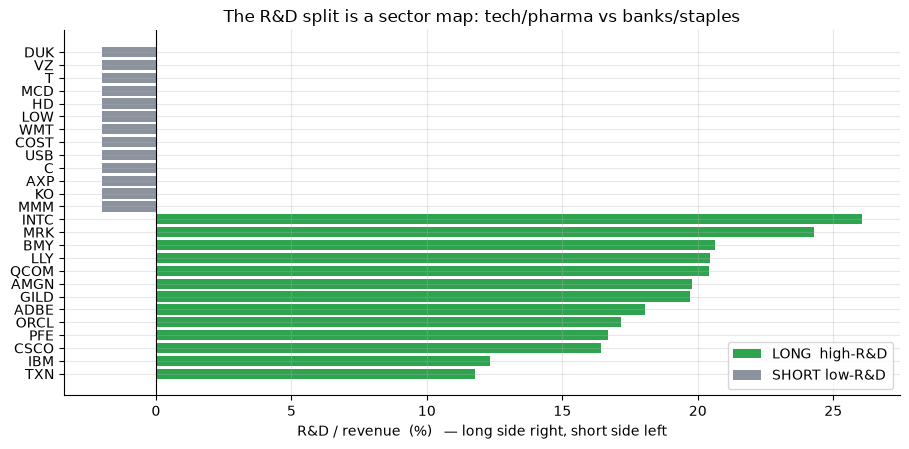

LONG : ['INTC', 'MRK', 'BMY', 'LLY', 'QCOM', 'AMGN', 'GILD', 'ADBE', 'ORCL', 'PFE', 'CSCO', 'IBM', 'TXN']
SHORT: ['MMM', 'KO', 'AXP', 'C', 'USB', 'COST', 'WMT', 'LOW', 'HD', 'MCD', 'T', 'VZ', 'DUK']


In [2]:
if HAVE_REAL:
    last = max(RACE['members']); lo, sh = RACE['members'][last]
    x = st.known_intensity(INTEN, last)
else:
    lo, sh = R['long_members'], R['short_members']
    x = None
fig, ax = plt.subplots(figsize=(9.2, 4.6))
if x is not None:
    xl = x[lo].sort_values(); xs = x[sh].sort_values()
    ax.barh([f'{t}' for t in xl.index], xl.values*100, color=GREEN, label='LONG  high-R&D')
    ax.barh([f'{t}' for t in xs.index], -xs.values*100-2, color=GREY, label='SHORT low-R&D')
    ax.set_xlabel('R&D / revenue  (%)   — long side right, short side left')
else:
    ax.barh(lo, [1]*len(lo), color=GREEN, label='LONG  high-R&D (tech/pharma)')
    ax.barh(sh, [-1]*len(sh), color=GREY, label='SHORT low-R&D (banks/staples)')
    ax.set_xlabel('(install the cache to see real intensities)')
ax.axvline(0, c='k', lw=.8); ax.set_title('The R&D split is a sector map: tech/pharma vs banks/staples')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()
print('LONG :', lo)
print('SHORT:', sh)

Long: chips (INTC, TXN, QCOM, CSCO), software (ADBE, ORCL, IBM), pharma/biotech (LLY, MRK, PFE, BMY, AMGN, GILD). Short: banks (C, USB, AXP), staples & retail (KO, WMT, COST, HD, LOW, MCD), telco/utility (T, VZ, DUK), industrials (MMM). That's not an innovation list — **that's the growth-vs-value lineup.** Hold that thought.

**Does the gap pay?** The long (high-R&D), the short leg (low-R&D), the long-minus-short spread, and the market — growth of \$1 over 21 years.

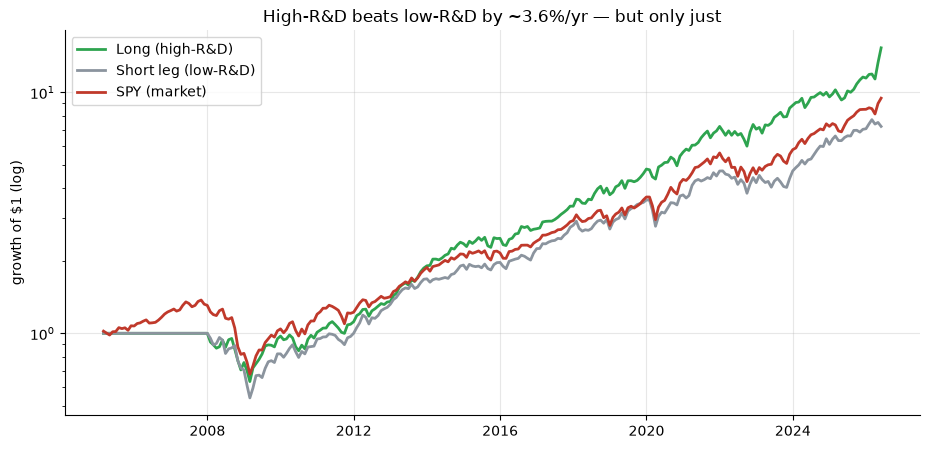

long CAGR 13.6%  short CAGR 9.7%  spread +3.6%/yr  SPY 11.1%


In [3]:
if HAVE_REAL:
    L, S, LS, MKT = RACE['long'], RACE['short'], RACE['long_short'], RACE['spy']
    eqs = {'Long (high-R&D)': (1+L).cumprod(), 'Short leg (low-R&D)': (1+S).cumprod(),
           'SPY (market)': (1+MKT).cumprod()}
    idx = L.index
else:
    idx = np.arange(R['months'])
    g = lambda m: (1+np.full(R['months'], (1+m/100)**(1/12)-1)).cumprod()
    eqs = {'Long (high-R&D)': g(R['long'][3]), 'Short leg (low-R&D)': g(R['short'][3]),
           'SPY (market)': g(R['spy'][3])}
fig, ax = plt.subplots(figsize=(9.4, 4.6))
for (name, eq), c in zip(eqs.items(), [GREEN, GREY, RED]):
    ax.plot(idx, np.asarray(eq), c=c, lw=2, label=name)
ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log)')
ax.set_title(f"High-R&D beats low-R&D by ~{R['test_ls'][0]:.1f}%/yr — but only just")
ax.legend(); plt.tight_layout(); plt.show()
print(f"long CAGR {R['long'][0]:.1f}%  short CAGR {R['short'][0]:.1f}%  "
      f"spread {R['long_short'][3]:+.1f}%/yr  SPY {R['spy'][0]:.1f}%")

The high-R&D side *does* finish ahead — **+3.6%/yr** over the low-R&D side. So the directional claim isn't nothing. The question is whether **+3.6%/yr** over 21 wobbly years is a *signal* or just the kind of gap luck throws up. That's the next chart.

**Is +3.6%/yr more than luck — and more than *any* split?** We draw 2,000 *random* long/shorts from the same names (no R&D used) and see where the R&D split lands.

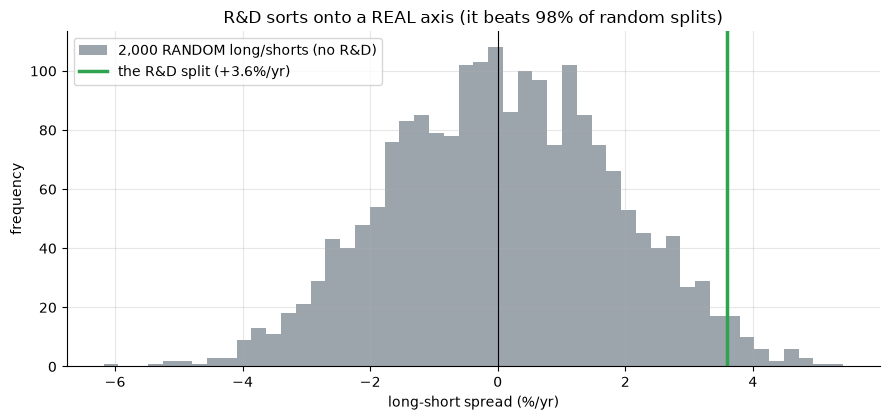

random split pays ~0%/yr; the R&D split pays +3.6%/yr -> R&D is NOT a generic split
...but its OWN t-stat is 1.50 (below 2): real axis, not significant return


In [4]:
if HAVE_REAL:
    rand = RACE['rand_ls_spread']*100; obs = R['test_ls'][0]; pct = RACE['ls_pctile']
else:
    rng = np.random.default_rng(400); rand = rng.normal(R['rand_mean'], R['rand_sd'], 2000)
    obs = R['test_ls'][0]; pct = R['ls_pctile']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(rand, bins=50, color=GREY, alpha=.85, label='2,000 RANDOM long/shorts (no R&D)')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'the R&D split ({obs:+.1f}%/yr)')
ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('long-short spread (%/yr)'); ax.set_ylabel('frequency')
ax.set_title(f'R&D sorts onto a REAL axis (it beats {pct:.0f}% of random splits)')
ax.legend(); plt.tight_layout(); plt.show()
print(f'random split pays ~0%/yr; the R&D split pays {obs:+.1f}%/yr -> R&D is NOT a generic split')
print(f"...but its OWN t-stat is {R['test_ls'][1]:.2f} (below 2): real axis, not significant return")

Two things at once, and both are honest. The R&D split lands at the **98th percentile** of random splits — so R&D is **not** a coin flip; it really does pick a persistent axis a random split misses. **But** that axis is the *tech-vs-value* axis (look at the names), and its own return gap, judged over 21 years, has a *t*-stat of just **1.50** — below the **2** bar. A real *style* tilt, not a significant *innovation* edge.

## 5 · The verdict

- **Signal — Weak.** High-R&D beats low-R&D by **+3.6%/yr** and the split is a real axis — but the gap fails the significance bar (HAC *t* = 1.50) and only clears it when you *barely* sort. Real-ish, but not certifiable.
- **Tradability — Mirage.** Shorting the low-R&D names costs borrow, which drops the gap to **+2.6%/yr at t = 1.08** — a net edge indistinguishable from zero.
- **An innovation premium? — Misattributed.** The high side *is* tech/pharma, the low side *is* banks/staples. You haven't found an innovation factor — you've relabelled **growth-vs-value**.

## 6 · Could you actually trade it? — the borrow bites

Forget significance for a second. Even taking the +3.6%/yr at face value, a long/short must *short* the low-R&D names — and you pay a borrow fee to do it. Here's the gap before and after a modest 1%/yr borrow on the short leg.

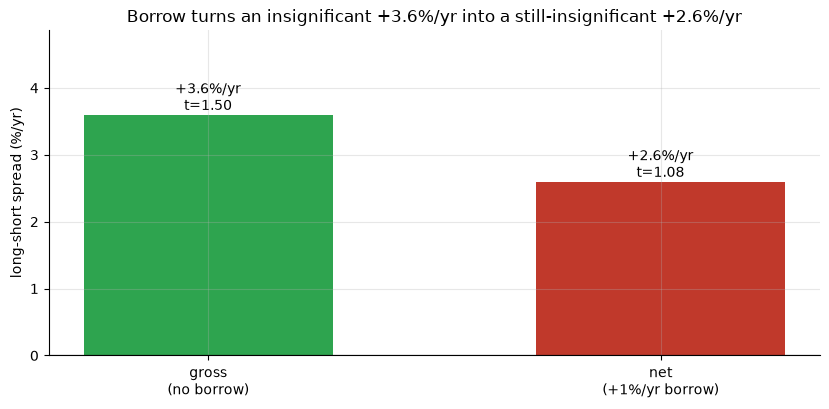

gross +3.6%/yr (t=1.50) -> net +2.6%/yr (t=1.08): both below t=2


In [5]:
g, gt = R['ls_gross']; n, nt = R['ls_net']
fig, ax = plt.subplots(figsize=(8.4, 4.2))
bars = ax.bar(['gross\n(no borrow)', 'net\n(+1%/yr borrow)'], [g, n],
              color=[GREEN, RED], width=.55)
for b, v, t in zip(bars, [g, n], [gt, nt]):
    ax.annotate(f'{v:+.1f}%/yr\nt={t:.2f}', (b.get_x()+b.get_width()/2, v),
                ha='center', va='bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('long-short spread (%/yr)')
ax.set_ylim(0, max(g, n)*1.35)
ax.set_title('Borrow turns an insignificant +3.6%/yr into a still-insignificant +2.6%/yr')
plt.tight_layout(); plt.show()
print(f'gross {g:+.1f}%/yr (t={gt:.2f}) -> net {n:+.1f}%/yr (t={nt:.2f}): both below t=2')

Turnover is trivial (you rebalance once a year), so trading cost isn't the killer. **Borrow is.** And the long-*only* version — just hold the high-R&D names, no shorting — beats SPY by a mere **+2.2%/yr (t = 1.21)**, almost all of which is the growth tilt you can buy as a cheap style ETF. There's no deployable innovation edge to harvest here.

## 7 · Going further 🚪

- **It's the *efficiency*, not the *spending*.** Hirshleifer-Hsu-Li (2013) show the premium that survives is **patents per R&D dollar** (innovative *efficiency*), not gross R&D intensity. Our proxy measures input, not output — swap in real patent/citation data and re-test.
- **Strip the style.** Regress the long-short on a growth-vs-value factor and ask if any *residual* innovation alpha survives. (Our random-split control already hints the answer is 'mostly style.')
- **Thematic siblings.** [Study 393 — AI-Datacenter-Basket](../../393-ai-datacenter-basket/) is the *selection* version of the same trap; here the trap is *attribution*.

*Think the innovation premium is real and distinct from growth? Show the long-short clearing t = 2 on a concentrated split, net of borrow, with the style beta stripped out — then we'll talk.*